In [57]:
from ray.tune import ExperimentAnalysis
from pathlib import Path
from utils.config import PROJECT_ROOT

In [58]:
import ray
print("Ray version:", ray.__version__)

Ray version: 2.46.0


In [59]:
root = Path(PROJECT_ROOT) / "cluster_ray_results"

analysis = ExperimentAnalysis(root / "hptuning_UNET_SE_remote/train_model_2025-06-17_11-03-58")

best_config = analysis.get_best_config(metric="val_loss", mode="min")
print("Best config:", best_config)

best_trial = analysis.get_best_trial(metric="val_loss", mode="min")
print("Best val_loss:", best_trial.metric_analysis["val_loss"]["min"])

ValueError: No experiment snapshot file of form 'experiment_state-*.json' was found at: (local, /mnt/c/Users/samue/SynologyDrive/OceanPropInfSatImg/cluster_ray_results/hptuning_UNET_SE_remote/train_model_2025-06-17_11-03-58)
Please check if you specified the correct experiment path, which should be a combination of the `storage_path` and `name` specified in your run.

In [60]:
from pathlib import Path
import json

files = ["hptuning_UNET_SE/train_model_2025-06-17_11-07-23", "hptuning_UNET_SE/train_model_2025-06-17_11-03-58"]

folder = root / files[0]
# folder = root

for file in files:
    folder = root / file
    print("Processing folder:", folder)
    results = []
    for trial_dir in folder.glob("train_model_*"):
        result_file = trial_dir / "result.json"
        if result_file.exists():
            with open(result_file) as f:
                last_result = json.loads(f.readlines()[-1])
                results.append({
                    "config": last_result.get("config"),
                    "val_loss": last_result.get("val_loss"),
                    "trial_dir": str(trial_dir)
                })

    # Find best by val_loss
    best = min(results, key=lambda r: r["val_loss"])
    print("Best config:", best["config"])
    print("Best val_loss:", best["val_loss"])

Processing folder: /mnt/c/Users/samue/SynologyDrive/OceanPropInfSatImg/cluster_ray_results/hptuning_UNET_SE/train_model_2025-06-17_11-07-23
Best config: {'lr': 0.0003575901700096904, 'batch_size': 200, 'grid_size': 21, 'base_filters': 16, 'reduction': 16}
Best val_loss: 0.42106853291194685
Processing folder: /mnt/c/Users/samue/SynologyDrive/OceanPropInfSatImg/cluster_ray_results/hptuning_UNET_SE/train_model_2025-06-17_11-03-58
Best config: {'lr': 0.00011668956799326319, 'batch_size': 200, 'grid_size': 21, 'base_filters': 16, 'reduction': 16}
Best val_loss: 2.387587761001847


In [61]:
from pathlib import Path
import json

files = ["hptuning_EBAM_CNN_BoBDaily_1993-1993/train_model_2025-06-17_15-46-02"]

folder = root / files[0]
# folder = root

for file in files:
    folder = root / file
    print("Processing folder:", folder)
    results = []
    for trial_dir in folder.glob("train_model_*"):
        result_file = trial_dir / "result.json"
        if result_file.exists():
            with open(result_file) as f:
                last_result = json.loads(f.readlines()[-1])
                results.append({
                    "config": last_result.get("config"),
                    "val_loss": last_result.get("val_loss"),
                    "trial_dir": str(trial_dir)
                })

    # Find best by val_loss
    best = min(results, key=lambda r: r["val_loss"])
    print("Best config:", best["config"])
    print("Best val_loss:", best["val_loss"])

Processing folder: /mnt/c/Users/samue/SynologyDrive/OceanPropInfSatImg/cluster_ray_results/hptuning_EBAM_CNN_BoBDaily_1993-1993/train_model_2025-06-17_15-46-02
Best config: {'lr': 0.0011519075638910447, 'batch_size': 500, 'grid_size': 21, 'num_heads': 3}
Best val_loss: 0.012547730289460978


In [66]:
import os

root = Path(PROJECT_ROOT) / "cluster_ray_results"

def get_experiment_bestconfig(folder):
    # print("Processing folder:", folder)
    results = []
    for trial_dir in folder.glob("train_model_*"):
        result_file = trial_dir / "result.json"
        if result_file.exists():
            with open(result_file) as f:
                if os.stat(f.name).st_size == 0:
                    # print(f"File is empty: {f.name}")
                    continue
                # print(f"Processing file: {f.name}")
                last_result = json.loads(f.readlines()[-1])
                results.append({
                    "config": last_result.get("config"),
                    "val_loss": last_result.get("val_loss"),
                    "trial_dir": str(trial_dir)
                })

    # Find best by val_loss
    if not results:
        # print("No results found in folder:", folder)
        return 0, None
    best = min(results, key=lambda r: r["val_loss"])
    return len(results), best

for subfolder in root.iterdir():
    if not subfolder.is_dir():
        continue
    print("Folder:", subfolder.as_posix().split("/")[-1])
    for trial in subfolder.iterdir():
        if not trial.is_dir():
            continue
        print("Trial:", trial.as_posix().split("/")[-1])
        print("Best config:", get_experiment_bestconfig(trial))
    print("\n")



Folder: hptuning_DA_CNN
Trial: train_model_2025-06-17_11-33-54
Best config: (0, None)
Trial: train_model_2025-06-17_12-05-10
Best config: (0, None)
Trial: train_model_2025-06-17_13-13-42
Best config: (35, {'config': {'lr': 0.0002533448791360189, 'batch_size': 50, 'grid_size': 17, 'first_layer_filters': 64, 'kernel_size': 3}, 'val_loss': 4.783809135980937, 'trial_dir': '/mnt/c/Users/samue/SynologyDrive/OceanPropInfSatImg/cluster_ray_results/hptuning_DA_CNN/train_model_2025-06-17_13-13-42/train_model_7b1717c9_26_batch_size=50,first_layer_filters=64,grid_size=17,kernel_size=3,lr=0.0003_2025-06-18_06-05-45'})


Folder: hptuning_DA_CNN_BoBDaily_1993-1993
Trial: train_model_2025-06-17_15-46-41
Best config: (25, {'config': {'lr': 0.006591846230160316, 'batch_size': 100, 'grid_size': 17, 'first_layer_filters': 64, 'kernel_size': 3}, 'val_loss': 0.011473497900608112, 'trial_dir': '/mnt/c/Users/samue/SynologyDrive/OceanPropInfSatImg/cluster_ray_results/hptuning_DA_CNN_BoBDaily_1993-1993/train_mo

=== hptuning_DA_CNN ===
No data in train_model_2025-06-17_11-33-54
No data in train_model_2025-06-17_12-05-10


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

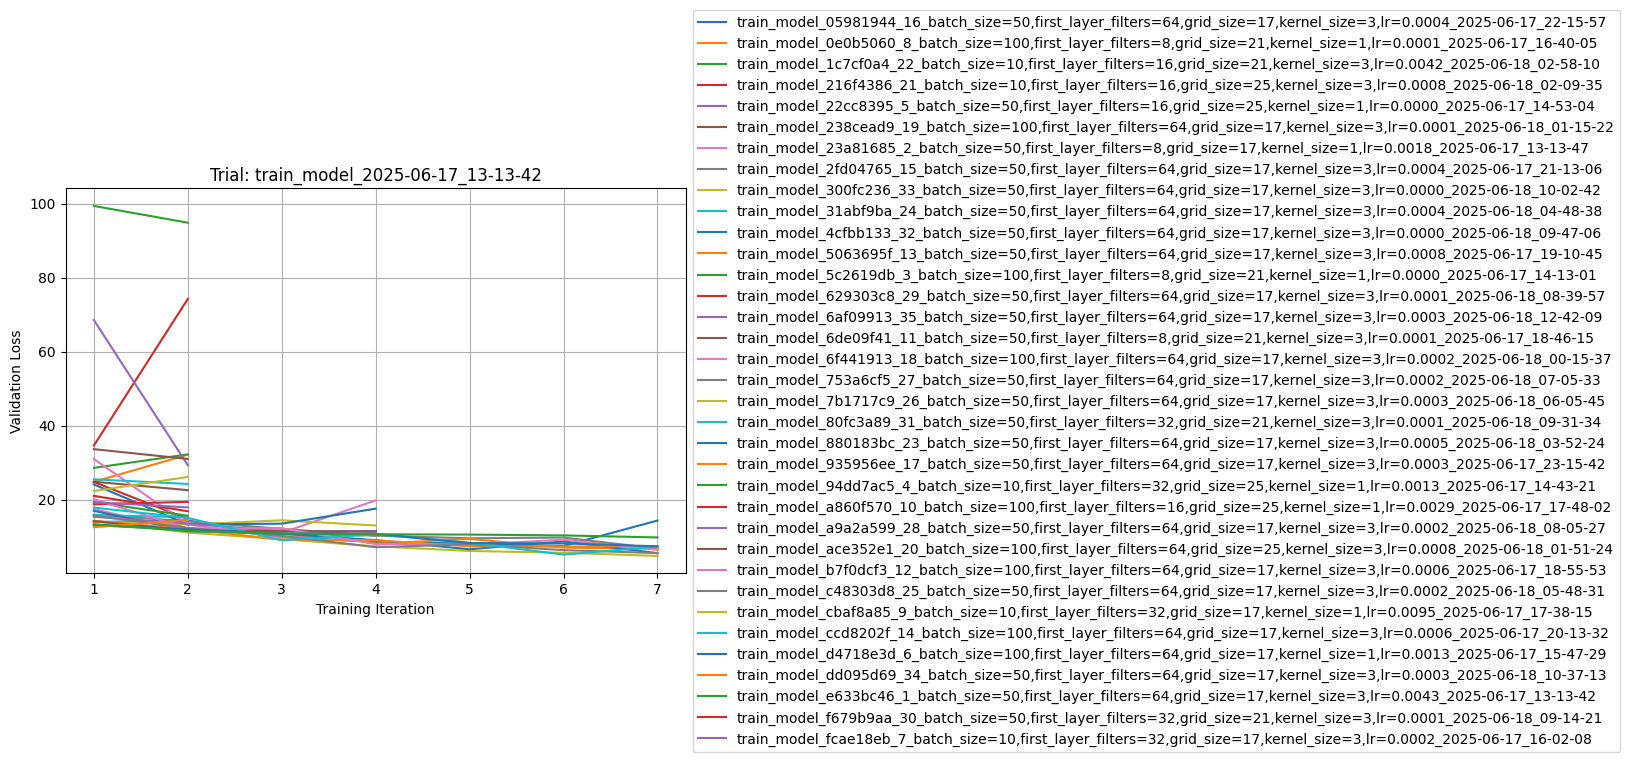

=== hptuning_DA_CNN_BoBDaily_1993-1993 ===


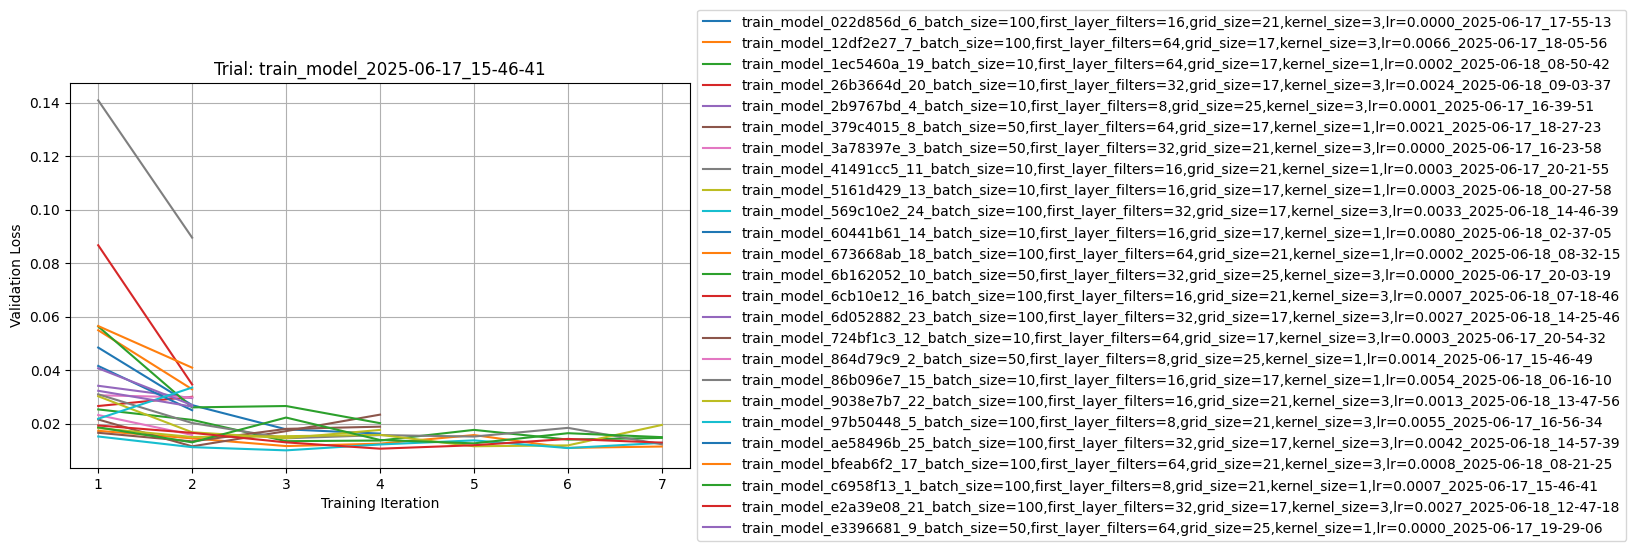

=== hptuning_DA_CNN_BoBMonthly_1993-2003 ===


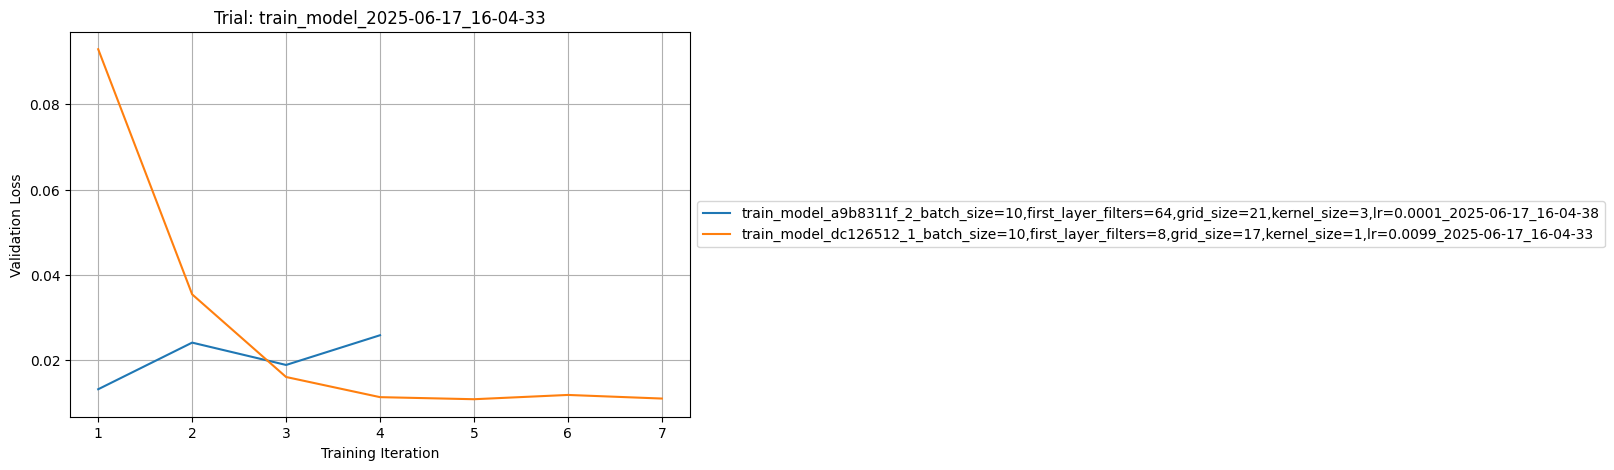

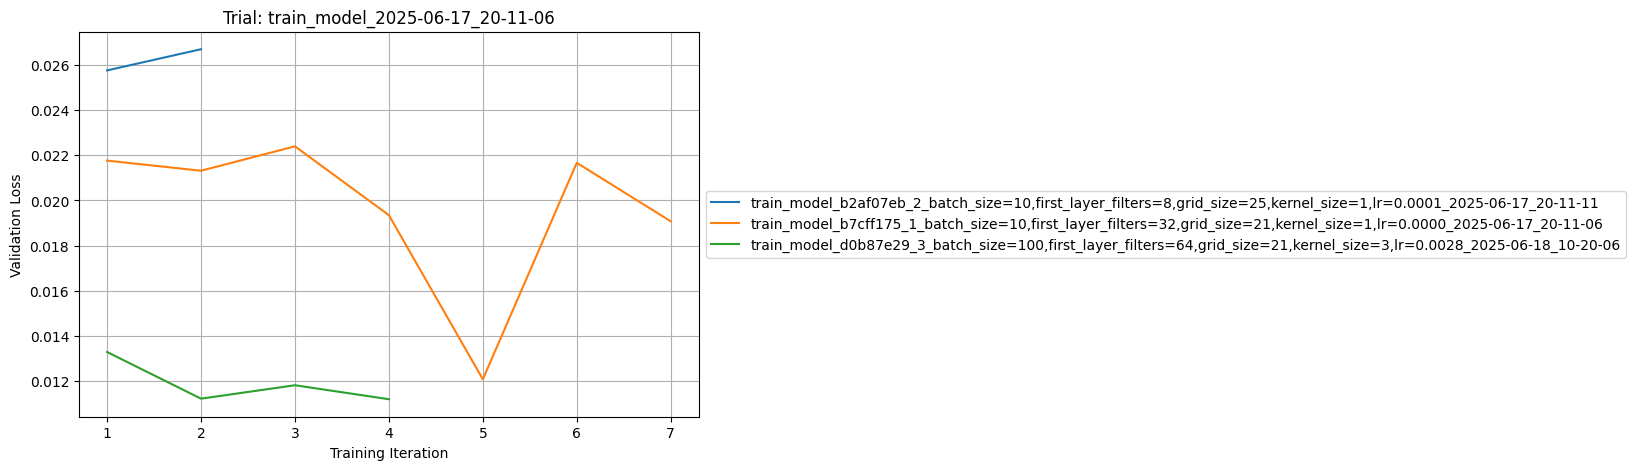

=== hptuning_DA_CNN_small_daily_alternative_sample_1993-1993 ===


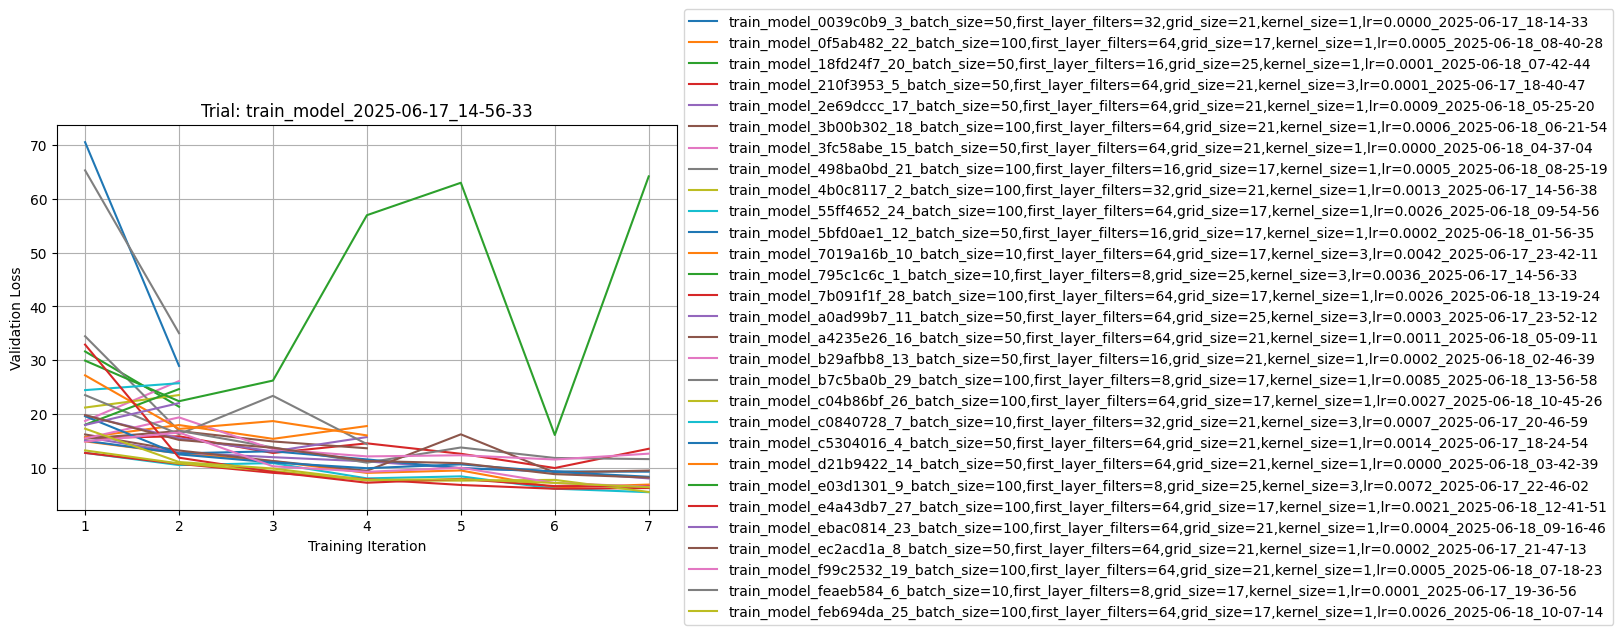

=== hptuning_DA_CNN_ten_sample_1993-2003 ===


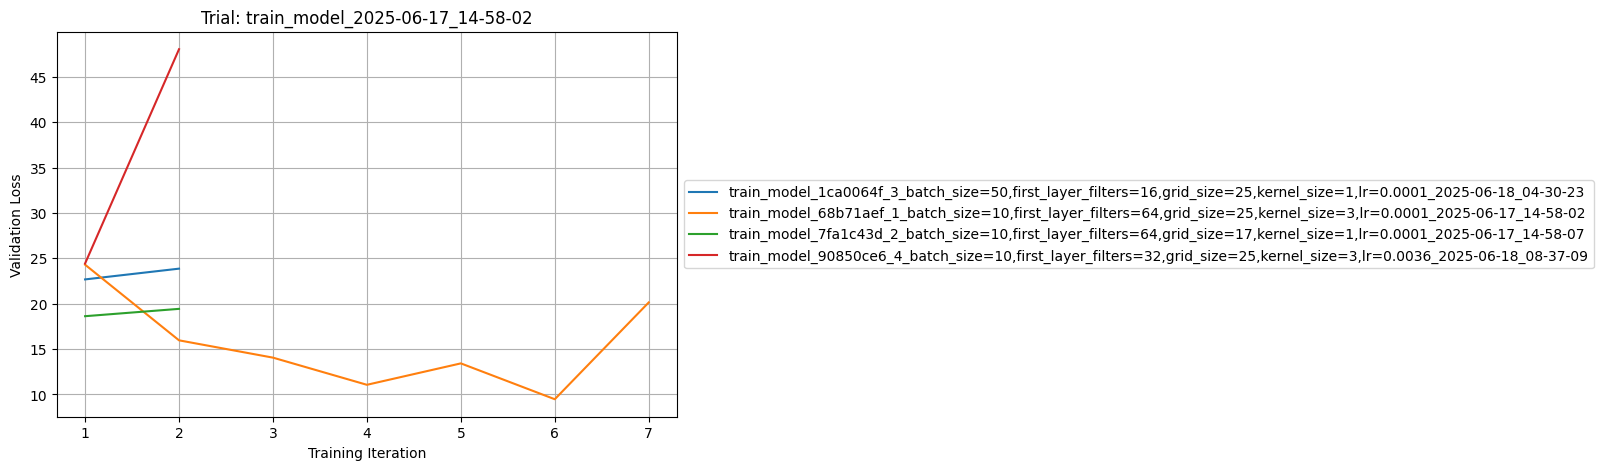

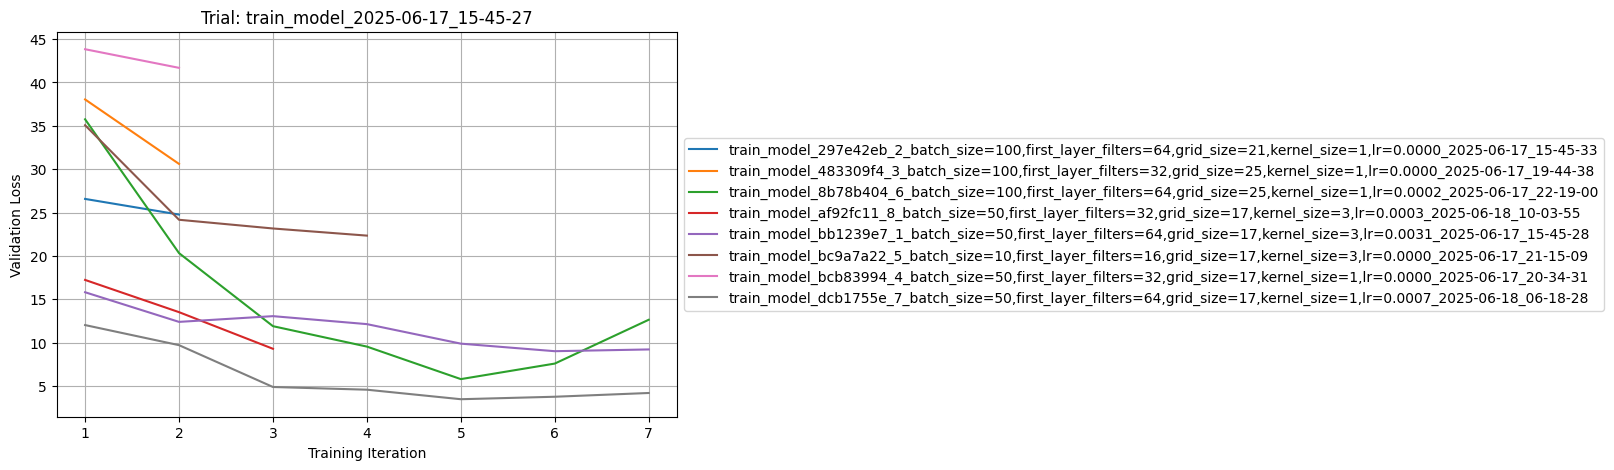

=== hptuning_EBAM_CNN ===


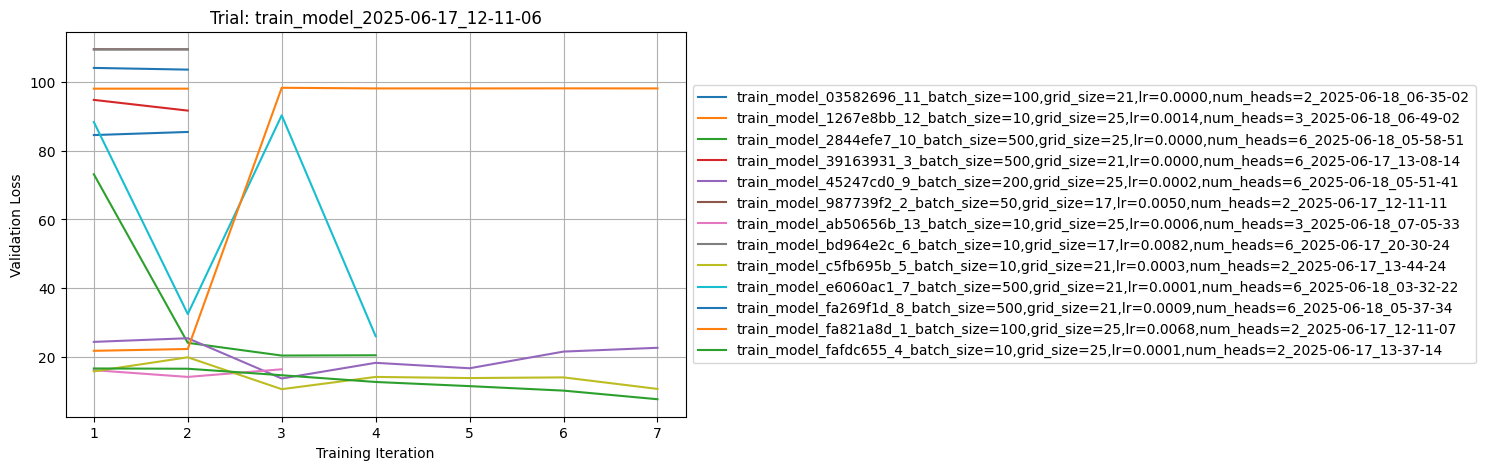

=== hptuning_EBAM_CNN_BoBDaily_1993-1993 ===


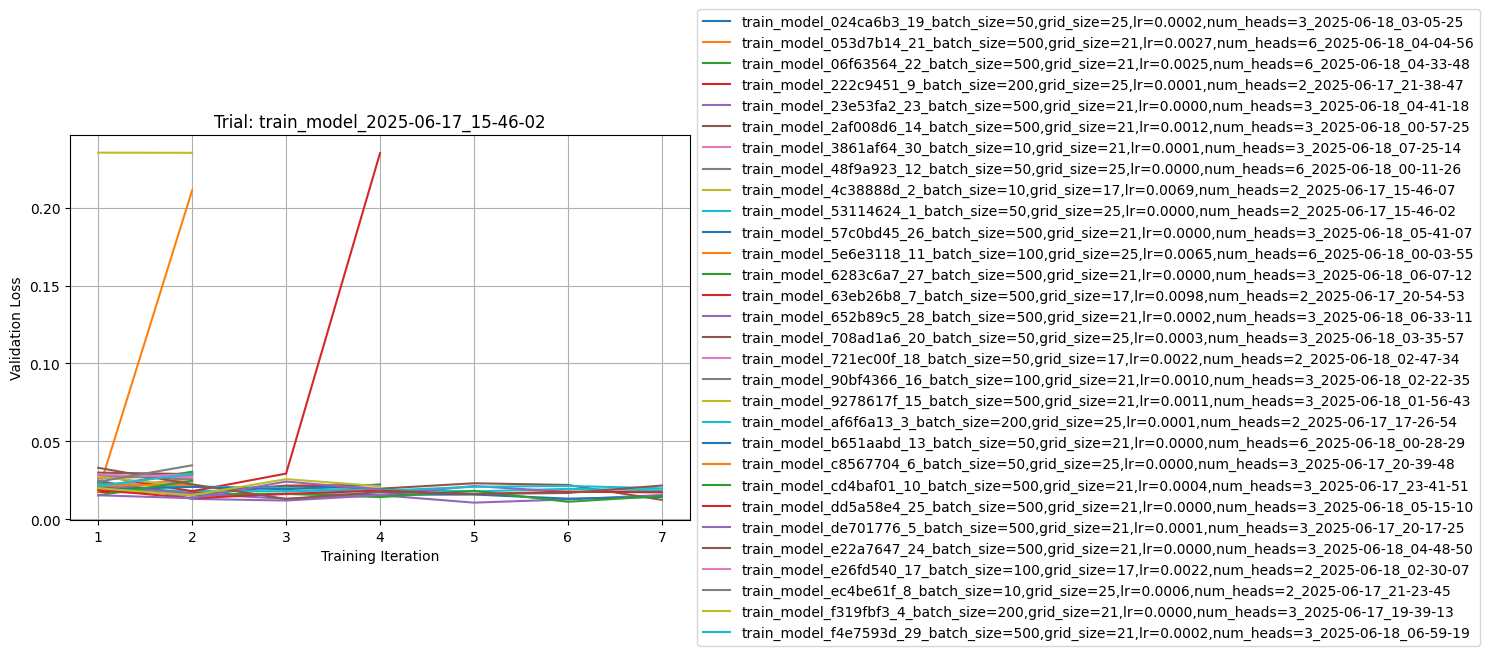

=== hptuning_EBAM_CNN_BoBMonthly_1993-2003 ===


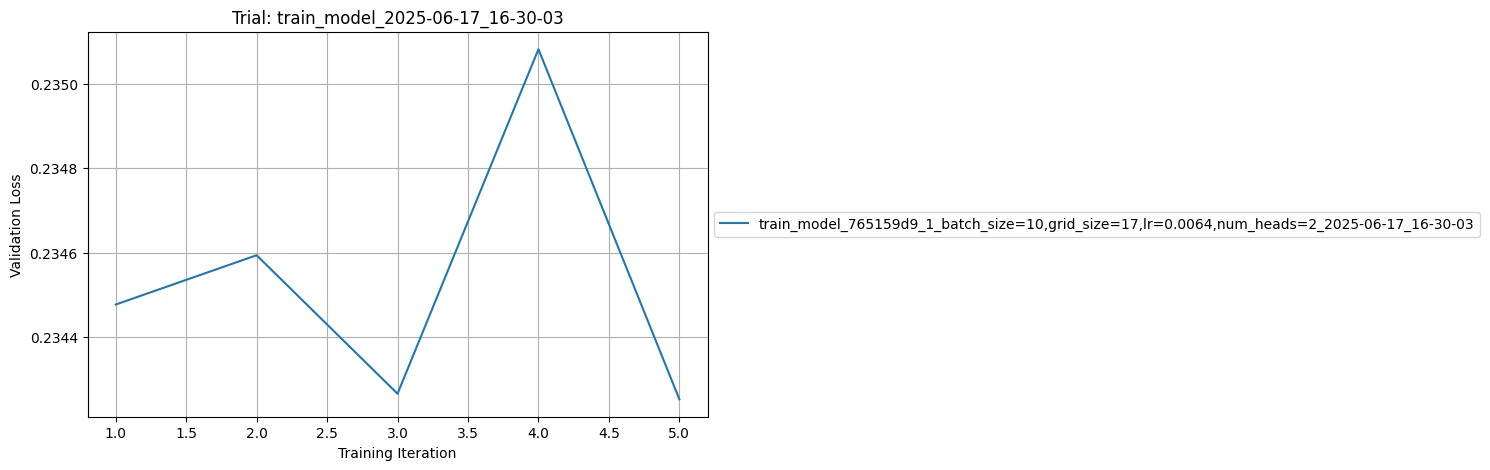

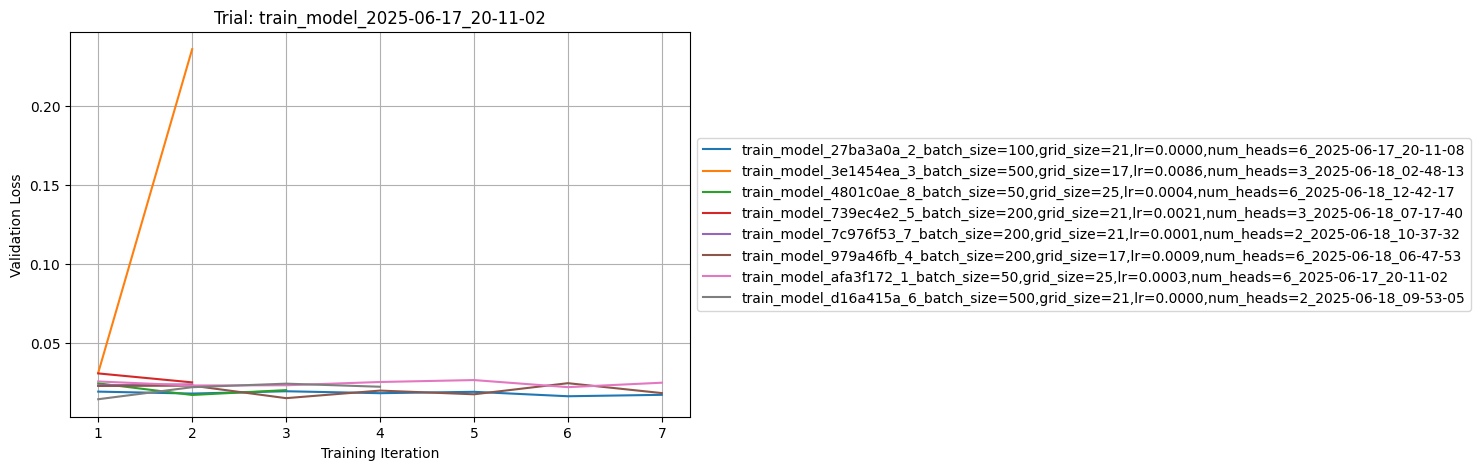

=== hptuning_EBAM_CNN_small_daily_alternative_sample_1993-1993 ===


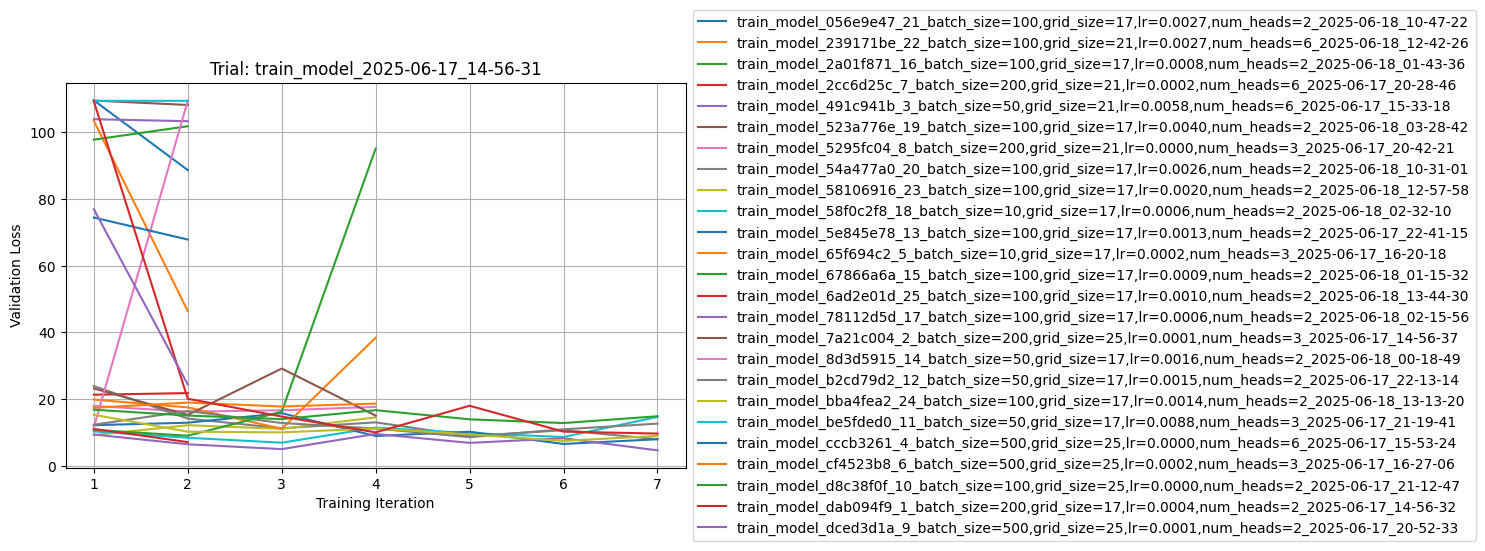

=== hptuning_EBAM_CNN_ten_sample_1993-2003 ===


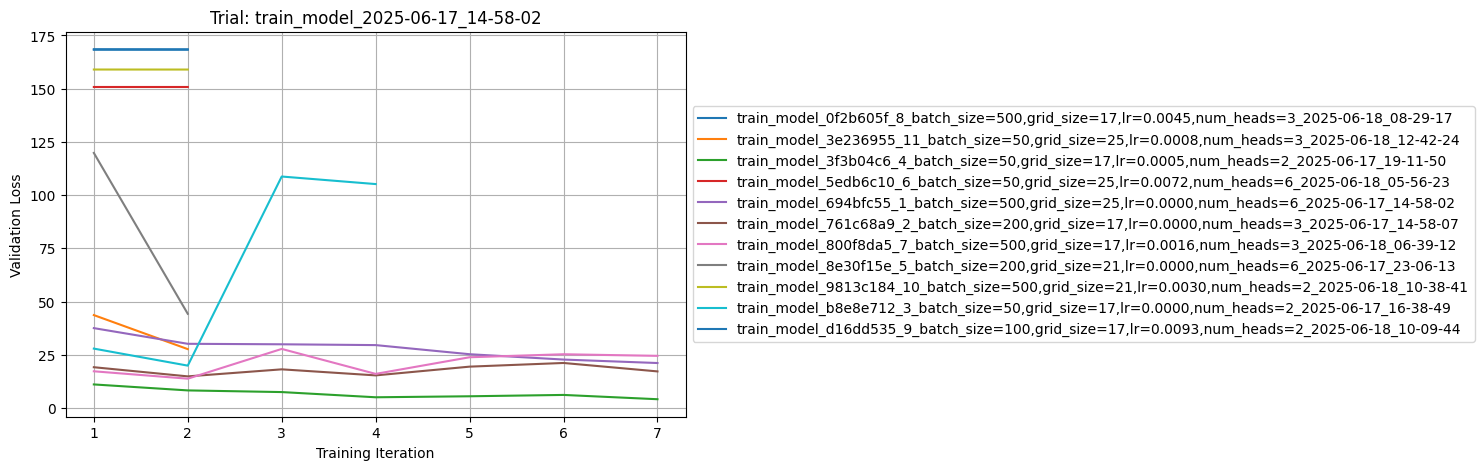

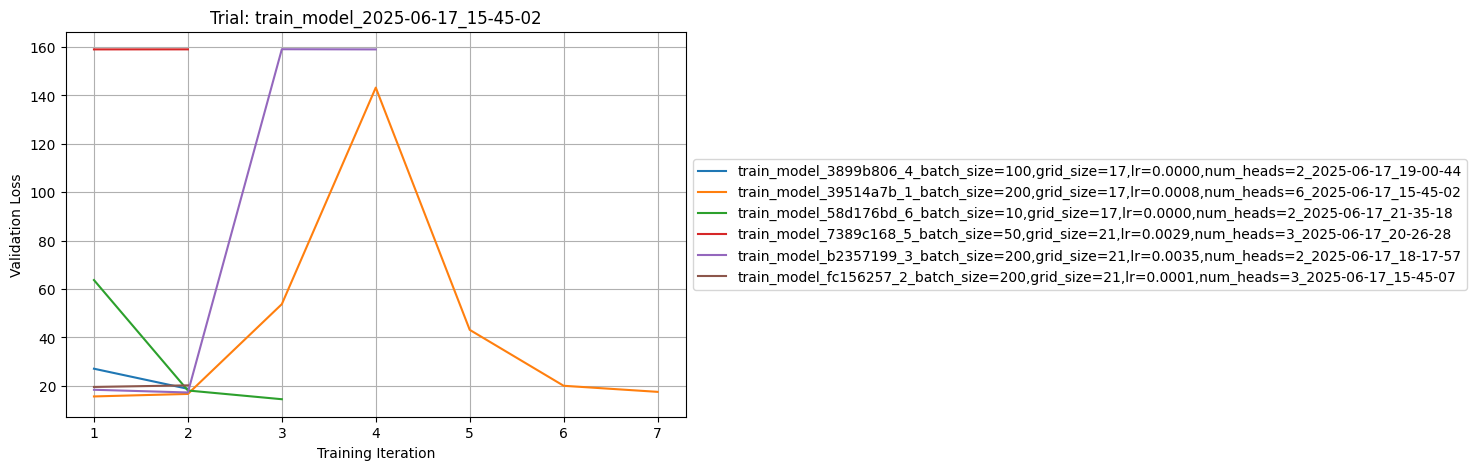

=== hptuning_UNET_SE ===
No data in train_model_2025-06-17_10-54-39


<Figure size 800x500 with 0 Axes>

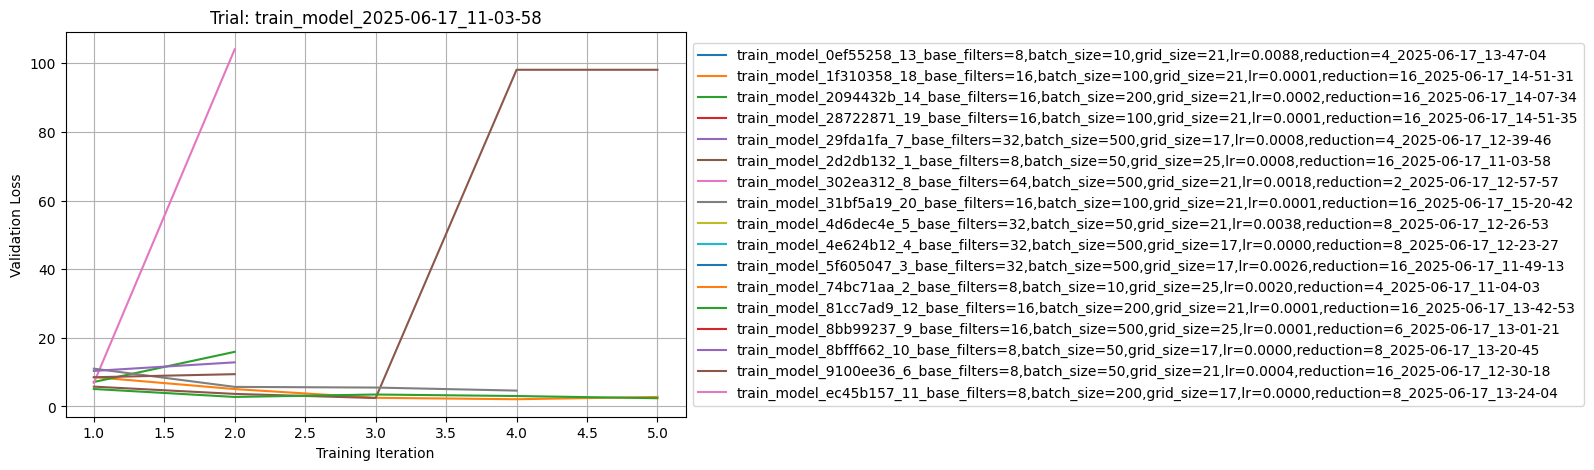

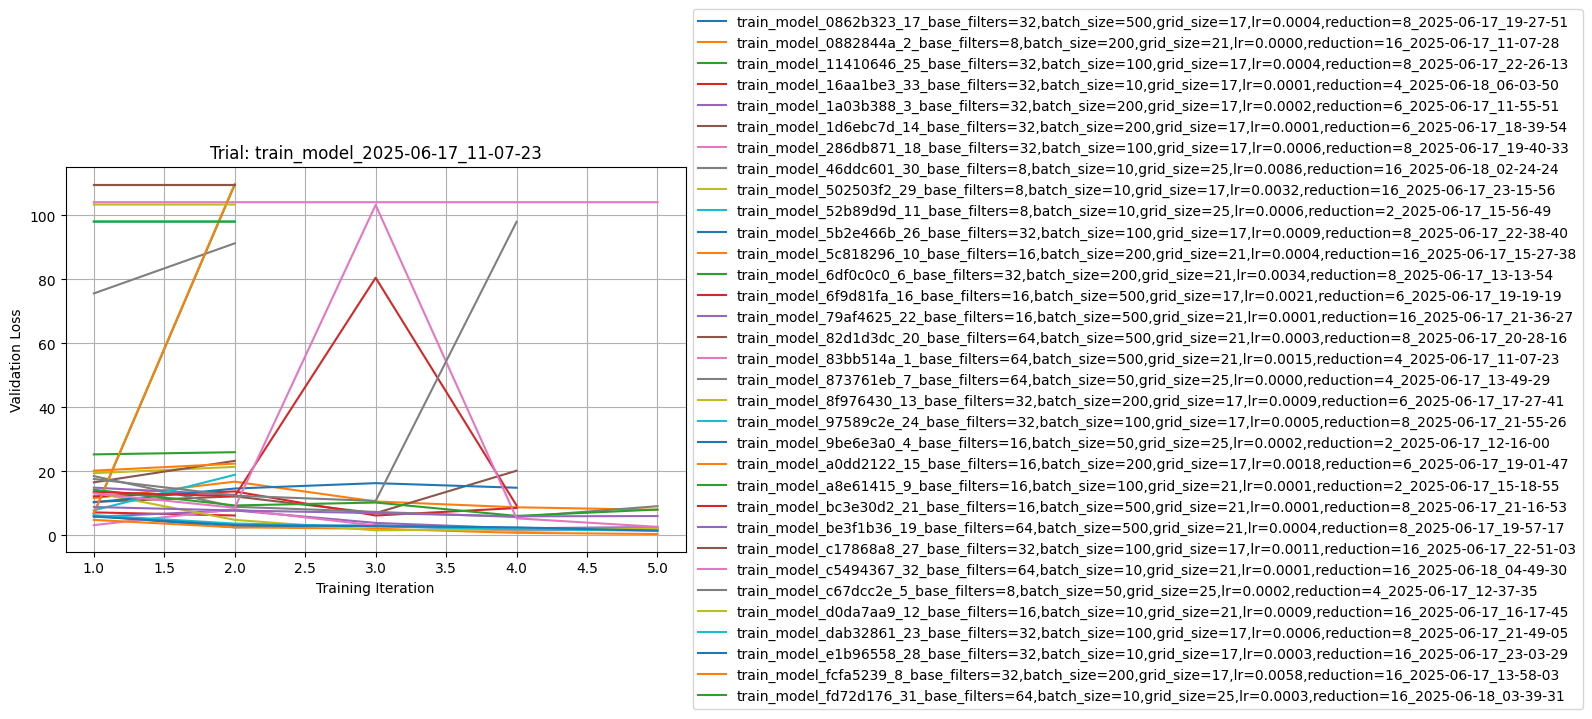

=== hptuning_UNET_SE_BoBDaily_1993-1993 ===


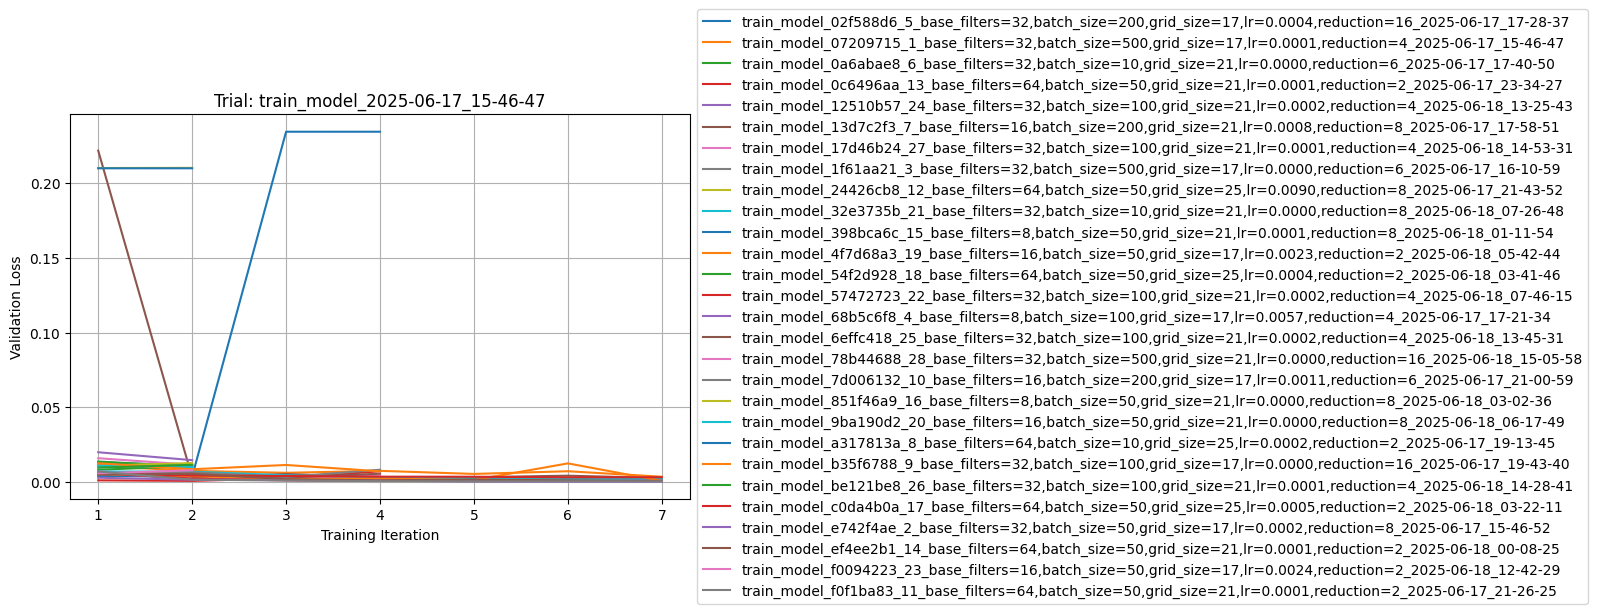

=== hptuning_UNET_SE_BoBMonthly_1993-2003 ===


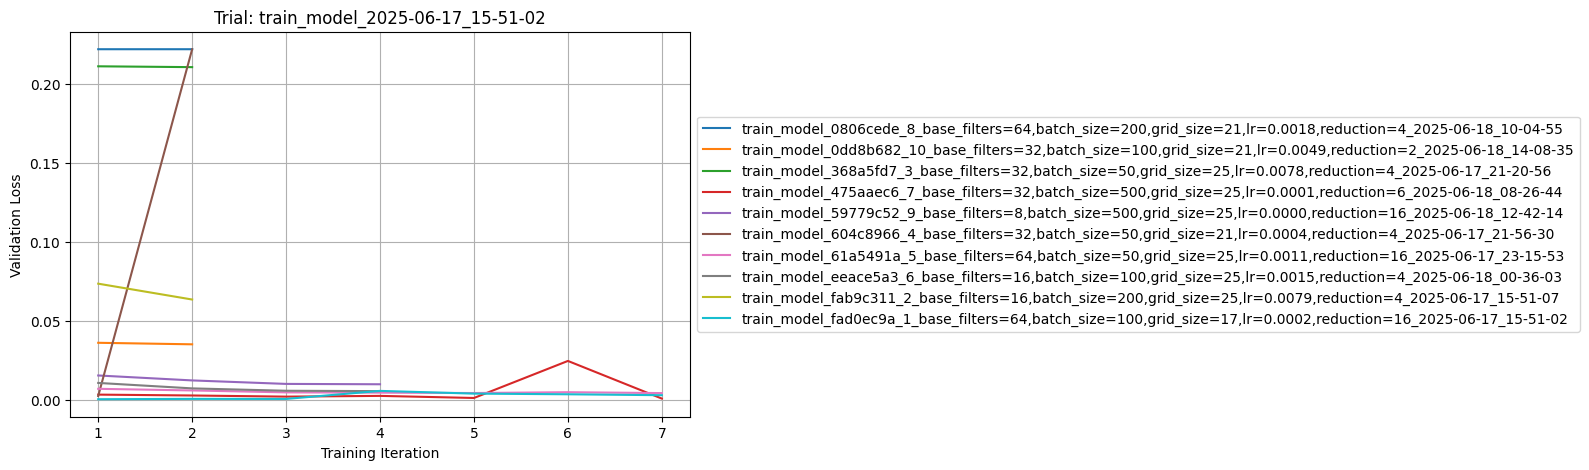

=== hptuning_UNET_SE_small_daily_alternative_sample_1993-1993 ===


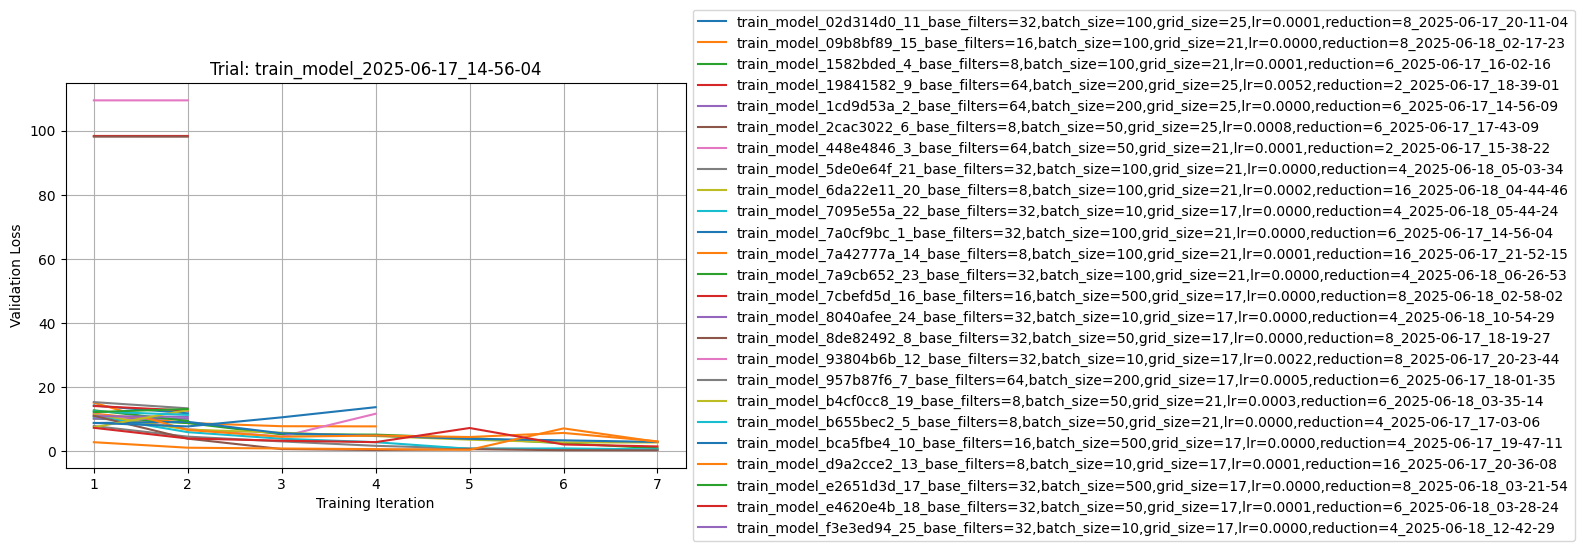

=== hptuning_UNET_SE_ten_sample_1993-2003 ===


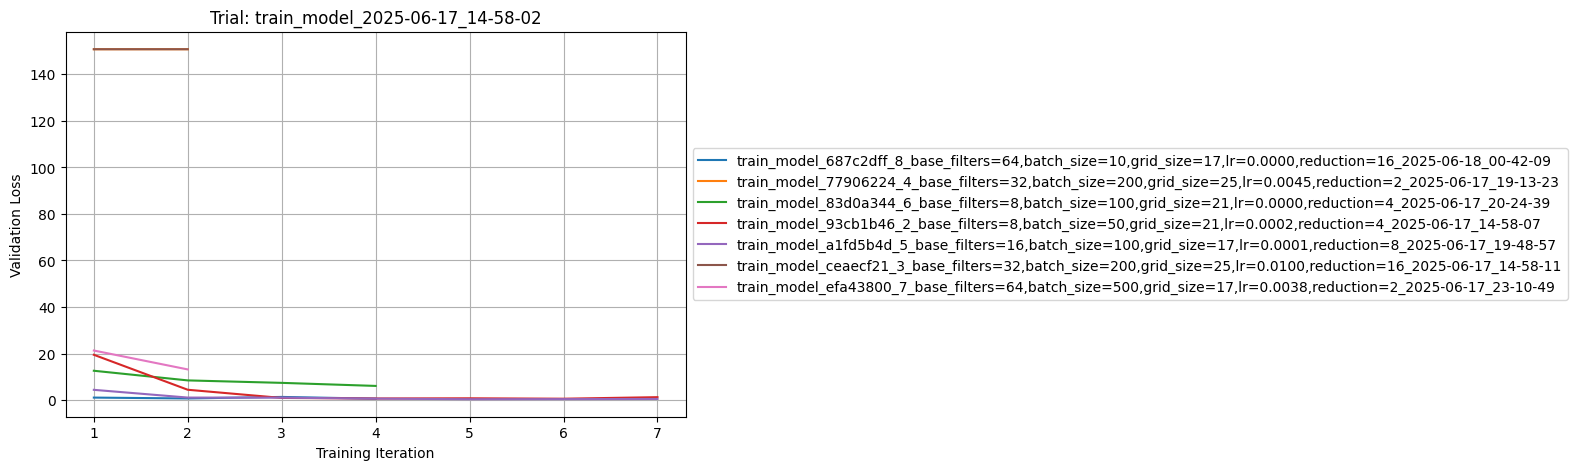

In [63]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

# ←– EDIT THIS to point at your actual folder
root = Path(PROJECT_ROOT) / "cluster_ray_results"

def plot_trial_progress(trial_folder: Path):
    """Plot val_loss vs training_iteration for each train_model_* run."""
    plt.figure(figsize=(8, 5))
    any_line = False
    for run_dir in trial_folder.glob("train_model_*"):
        result_file = run_dir / "result.json"
        if not result_file.exists() or result_file.stat().st_size == 0:
            continue
        iters, losses = [], []
        for line in result_file.read_text().splitlines():
            rec = json.loads(line)
            iters.append(rec["training_iteration"])
            losses.append(rec["val_loss"])
        if iters:
            plt.plot(iters, losses, label=run_dir.name)
            any_line = True

    if not any_line:
        print(f"No data in {trial_folder.name}")
        return

    plt.title(f"Trial: {trial_folder.name}")
    plt.xlabel("Training Iteration")
    plt.ylabel("Validation Loss")
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    plt.grid(True)
    plt.show()

# Walk all subfolders → trials → plot each
for subfolder in root.iterdir():
    if not subfolder.is_dir():
        continue
    print(f"=== {subfolder.name} ===")
    for trial in subfolder.iterdir():
        if trial.is_dir():
            plot_trial_progress(trial)
